### Multiplot for any rho experiment for a timeseries

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

In [2]:
dataf ="/Volumes/ESA_F4R/ed_prepare/2026_mergeds/" 
datao ="/Volumes/ESA_F4R/ed_prepare/2026_rho/nudge_mint_r02_it1000_tole3/" 
datap ="/Users/ellendyer/Documents/GitHub/Isotopes_F4R/plots/nudge_mint_r02_it1000_tole3/" 
datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"congo_basin_evergreen.shp")

S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_M" # L_M or L_HI
band = {'N':[5,12,10,31],'EQ':[-5,5,8,29],'S':[-15,-5,12,31]}
band = 'EQ'


In [3]:
rho_xarr={}
for B in [band]:
    print('running band:', B)
    rho_xarr[B] = xr.open_mfdataset(datao+L_NAME+"_"+S_NAME+"_band_"+B+"_rot_rho_era5_*.nc",engine='netcdf4')
    print(rho_xarr[B])

running band: EQ
<xarray.Dataset> Size: 45MB
Dimensions:  (rot: 4, time: 420, lat: 40, lon: 84)
Coordinates:
  * rot      (rot) int32 16B 1 2 3 4
  * time     (time) datetime64[ns] 3kB 1990-01-01 1990-02-01 ... 2024-12-01
  * lat      (lat) float64 320B -4.875 -4.625 -4.375 ... 4.375 4.625 4.875
  * lon      (lon) float64 672B 8.125 8.375 8.625 8.875 ... 28.38 28.62 28.88
Data variables:
    rho      (rot, time, lat, lon) float64 45MB dask.array<chunksize=(4, 12, 40, 84), meta=np.ndarray>
Attributes:
    description:  Recycling ratio
    units:        %


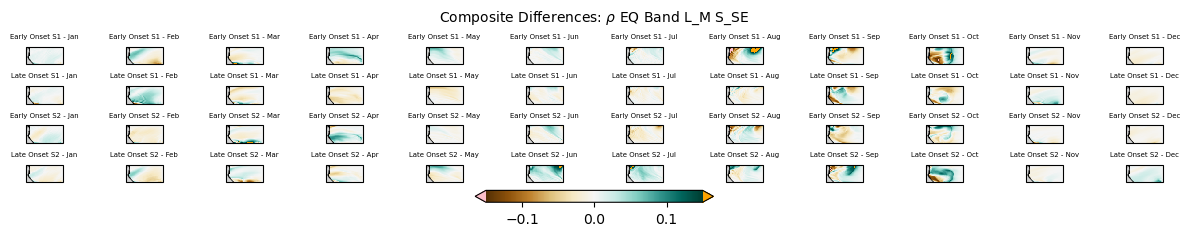

<Figure size 640x480 with 0 Axes>

In [5]:
#Composite year-month plots - average rotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

yearcomps = {}

#EQ
#yearcomps['Wet Season S1'] = [1997, 1996, 2009, 1991, 1999]
#yearcomps['Dry Season S1'] = [2024, 2004, 2015, 1998, 1994]
#yearcomps['Wet Season S2'] = [1997, 2000, 1990, 2018, 1999]
#yearcomps['Dry Season S2'] = [2015, 1991, 2024, 1996, 2014]

yearcomps['Early Onset S1'] = [2012, 2018, 1999, 2003, 1991]
yearcomps['Late Onset S1'] = [1995, 2000, 2011, 2004, 1994]
yearcomps['Early Onset S2'] = [2007, 2018, 1999, 2020, 1993]
yearcomps['Late Onset S2'] = [2019, 1991, 1996, 2017, 2015]


##N
#yearcomps['Dry Season S1'] = [2004, 2008, 2009, 1990, 2007]
#yearcomps['Wet Season S1'] = [1997, 2010, 1999, 2012, 2019]

ncols=12
nrows=len(yearcomps.keys())
h = nrows
w = ncols
cmap=plt.cm.BrBG
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for B in [band]:
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(12,2))
    
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()
    
    RHO = rho_xarr[B]['rho'].mean('rot')
    
    #Calculate composite differences from monthly means
    RHO = RHO.groupby('time.month') - RHO.groupby('time.month').mean('time') 
    
    ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)
    
    #Loop over all of the composites
    i = 0
    for T in yearcomps.keys():
    
            # Select the week 1 forecast from the specified model
            datac=RHO.sel(time=RHO['time.year'].isin(yearcomps[T])).groupby('time.month').mean('time')
            
            for t,ti in enumerate(datac['month']):
                
                data = datac[t]
    
                # Contour plot
                cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                                   data.values,
                                   vmin=-0.15,vmax=0.15,
                                   #levels=13,
                                   #extend='max',
                                   cmap=cmap,
                                   #aspect= ap,
                                   rasterized=True,
                                   transform = ccrs.PlateCarree())
        
                # Title each subplot with the name of the model
                #axs[i].set_title(T+' - '+str("{:02d}".format(data["month"].values)),fontsize=6)
                axs[i].set_title(T+' - '+mon[data["month"].values-1],fontsize=5)
        
                # Draw the coastines for each subplot
                axs[i].coastlines()
                axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
                i=i+1
    
    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(hspace=0,wspace=-0.5)
    # Draw the colorbar
    cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.2,extend="both",fraction=0.2)
    
    # Add a big title at the top
    plt.suptitle("Composite Differences: $\\rho$ "+B+" Band "+L_NAME+" "+S_NAME, fontsize=10,y=1.1,x=0.5)
    plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_composites.png",bbox_inches="tight",dpi=200)
    plt.show()
    plt.clf()
        

In [ ]:

#Individual year-month plots - average rotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=12
nrows=35
h = nrows
w = ncols
cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for B in [band]:
    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(15,24))
    
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()
    
    RHO = rho_xarr[B]['rho'].mean('rot')
    mtime = RHO['time']
    ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)
    
    #Loop over all of the models
    for i,T in enumerate(mtime):
    
            # Select the week 1 forecast from the specified model
            data=RHO.sel(time=T)
    
            # Contour plot
            cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                               data.values,
                               vmin=0.0,vmax=1.0,
                               #levels=13,
                               #extend='max',
                               cmap=cmap,
                               #aspect= ap,
                               rasterized=True,
                               transform = ccrs.PlateCarree())
    
            # Title each subplot with the name of the model
            axs[i].set_title(str(data["time.year"].values)+"-"+str("{:02d}".format(data["time.month"].values)),
                     fontsize=4)
    
            # Draw the coastines for each subplot
            axs[i].coastlines()
            axs[i].add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    
    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(hspace=0,wspace=-0.5)
    #plt.tight_layout()
    
    # Add a colorbar axis at the bottom of the graph
    #cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])

    # Draw the colorbar
    #cbar=fig.colorbar(cs,ax=cbar_ax,extend='both')#,shrink=0.5)
    cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.2,extend="both",fraction=0.2)
    
    # Add a big title at the top
    plt.suptitle("$\\rho$ "+B+" Band "+L_NAME+" "+S_NAME, fontsize=10,y=1.01,x=0.5)
    plt.savefig(datap+B+"_"+L_NAME+"_"+S_NAME+"_rotmean.png",bbox_inches="tight",dpi=200)
    plt.show()
    plt.clf()
        

KeyboardInterrupt: 

In [ ]:
sys.exit()

SystemExit: 

In [ ]:
##Filtering out outliers for plotting 
#for B in ['N','S','EQ']:
#    for r in np.arange(1,5):
#        print("*** Rotation is: ",r)
#        try:
#            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<=1.0,1.0)
#            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>0.0,0.0)
#            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
#            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
#            print('-------------------------')
#        except:
#            print('No outliers')
#            print(rho_xarr[B])

#Filtering out outliers for plotting 
for B in ['EQ']:
    for r in np.arange(1,5):
        print("*** Rotation is: ",r)
        try:
            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<=1.0,np.nan)
            rho_xarr[B]['rho'][r-1,:,:,:] = rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>0.0,np.nan)
            print('Number of rhos over 1: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values>1.0).count().values)
            print('Number of negative rhos: ', rho_xarr[B]['rho'][r-1,:,:,:].where(rho_xarr[B]['rho'][r-1,:,:,:].values<0.0).count().values)
            print('-------------------------')
        except:
            print('No outliers')
            print(rho_xarr[B])

*** Rotation is:  1
Number of rhos over 1:  136
Number of negative rhos:  1754
Number of rhos over 1:  0
Number of negative rhos:  0
-------------------------
*** Rotation is:  2
Number of rhos over 1:  142
Number of negative rhos:  1766
Number of rhos over 1:  0
Number of negative rhos:  0
-------------------------
*** Rotation is:  3
Number of rhos over 1:  129
Number of negative rhos:  1557
Number of rhos over 1:  0
Number of negative rhos:  0
-------------------------
*** Rotation is:  4
Number of rhos over 1:  125
Number of negative rhos:  1602
Number of rhos over 1:  0
Number of negative rhos:  0
-------------------------
